In [1]:
#!rm -rf /content/mos2*  

## This command can be used to clean up previous runs when needed.
## Be careful with this command when running on your local machine! It will delete files permanently.

In [2]:
#!unzip image_data.zip -d /content/    

## enbale this command only for the first time to unzip the data.

# Image Segmentation using U-Net  (Student Copy)

This notebook combines dataset preparation, U-Net training, and inference into a single end-to-end workflow.


**Grading breakdown (100 pts total):**

| Component | Points |
|-----------|--------|
| Q1 Train/Val Split | 10 |
| Q2 Patch Extraction | 10 |
| Q3 Augmentation | 10 |
| Q4 Class Imbalance | 10 |
| Q5 U-Net Architecture | 10 |
| Q6 Loss Function | 10 |
| Q7 Training Dynamics | 10 |
| Q8 Evaluation and Improvement Plan | 10 |
| Optimised model (both training and val defect IoU improvement, better masks predictions for unlabeled test images) | 20 |
| **Total** | **100** |

> **Tip:** After answering all questions, apply your improvement plan and re-run. The 20 optimisation points are awarded based on how much your final val defect IoU exceeds this baseline, and also how well your predictions on the unlabeled test images.

In [3]:
# Check PyTorch installation and GPU availability on Google Colab

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"Is CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.9.1+cu128
Is CUDA available: True
GPU Device: NVIDIA RTX A2000 12GB


---
# Part 1 -- Dataset Preparation

Converts LabelMe polygon annotations into **U-Net** binary integer masks (PNG).

In [4]:
import os, json, shutil
import numpy as np
from PIL import Image, ImageDraw
from sklearn.model_selection import train_test_split

# ============================================================
# Settings
# ============================================================
DATA_DIR     = './mos2'                     # training images + labels
VAL_DIR      = './mos2_val_images_labeled'   # validation images + labels
TEST_DIR     = './mos2_test_images_unlabeled' # unlabeled test images
OUT_DIR      = './mos2_dataset'              # output root

PATCH        = 256                # smaller patches for the next U-Net ablation
REMOVE_EMPTY = True               # skip patches with no annotations
RANDOM_SEED  = 42

# Label → class index mapping (background = 0)
LABEL_MAP = {
    'defect': 1,
}
NUM_CLASSES = 2   # background + defect


print('Settings OK')
print(f'  PATCH={PATCH}, REMOVE_EMPTY={REMOVE_EMPTY}')
print(f'  NUM_CLASSES={NUM_CLASSES} (including background)')

Settings OK
  PATCH=256, REMOVE_EMPTY=True
  NUM_CLASSES=2 (including background)


In [5]:
# ============================================================
# Output folder structure
# ============================================================
if os.path.exists(OUT_DIR):
    shutil.rmtree(OUT_DIR)

paths = {}
for split in ['train', 'val']:
    for sub in ['images', 'masks']:
        p = os.path.join(OUT_DIR, sub, split)
        os.makedirs(p, exist_ok=True)
        paths[f'{sub}_{split}'] = p

print('Output folders created:')
for k, v in paths.items():
    print(f'  {v}')


Output folders created:
  ./mos2_dataset\images\train
  ./mos2_dataset\masks\train
  ./mos2_dataset\images\val
  ./mos2_dataset\masks\val


In [6]:
# ============================================================
# Helpers: mask from LabelMe JSON
# ============================================================

def load_multiclass_mask(json_path, image_size):
    """Returns an (H, W) uint8 array: 0=background, 1=defect."""
    with open(json_path) as f:
        data = json.load(f)

    w, h = image_size
    mask = Image.new('L', (w, h), 0)
    draw = ImageDraw.Draw(mask)

    for s in data['shapes']:
        label = s['label']
        if label not in LABEL_MAP or s['shape_type'] != 'polygon':
            continue
        pts = [tuple(p) for p in s['points']]
        draw.polygon(pts, fill=LABEL_MAP[label])

    return np.array(mask, dtype=np.uint8)



print('Helpers defined.')


Helpers defined.


In [7]:
# ============================================================
# Augmentation helpers
# ============================================================

# Baseline: only 2 transforms (original + horizontal flip)
# TODO: restore full augmentation -- add 'flipud', 'rot90', 'rot180', 'rot270'
AUG_TAGS = ['orig', 'fliplr']

def augment_array(arr, tag):
    if tag == 'fliplr':  return np.fliplr(arr)
    if tag == 'flipud':  return np.flipud(arr)
    if tag == 'rot90':   return np.rot90(arr, 1)
    if tag == 'rot180':  return np.rot90(arr, 2)
    if tag == 'rot270':  return np.rot90(arr, 3)
    return arr  # 'orig'


print('Augmentation helpers defined.')


Augmentation helpers defined.


In [8]:
# ============================================================
# Collect image/json pairs
# ============================================================
def collect_pairs(directory):
    pairs = []
    for f in os.listdir(directory):
        if f.endswith('.json'):
            stem = f.replace('.json', '')
            img_path = os.path.join(directory, stem + '.png')
            if os.path.exists(img_path):
                pairs.append(stem)
    pairs.sort(key=lambda x: int(x) if x.isdigit() else x)
    return pairs

train_pairs = collect_pairs(DATA_DIR)
val_pairs   = collect_pairs(VAL_DIR)

print(f'Train labeled images ({len(train_pairs)}): {train_pairs}')
print(f'Val labeled images   ({len(val_pairs)}): {val_pairs}')


Train labeled images (5): ['18', '19', '23', '26', '28']
Val labeled images   (3): ['13', '25', '27']


In [9]:
# ============================================================
# Train / val split (pre-defined by folder structure)
# ============================================================
train_ids = train_pairs
val_ids   = val_pairs

print(f'Train: {len(train_ids)} images')
print(f'Val:   {len(val_ids)} images')
print(f'Val IDs: {sorted(val_ids)}')


Train: 5 images
Val:   3 images
Val IDs: ['13', '25', '27']


In [10]:
# ============================================================
# Patch extraction + dataset generation
# ============================================================

def process_split(ids, img_dir, mask_dir, src_dir=None, augment=False):
    if src_dir is None:
        src_dir = DATA_DIR
    count = 0
    skipped_empty = 0

    for stem in ids:
        img_pil  = Image.open(os.path.join(src_dir, stem + '.png')).convert('L')
        img_np   = np.array(img_pil)
        h, w     = img_np.shape

        mask_np  = load_multiclass_mask(
            os.path.join(src_dir, stem + '.json'),
            img_pil.size  # (w, h)
        )

        # Tile into PATCH x PATCH patches
        patch_coords = [
            (x, y)
            for y in range(0, h - PATCH + 1, PATCH)
            for x in range(0, w - PATCH + 1, PATCH)
        ]

        # If image is smaller than PATCH in any dim, use (0,0) as single patch
        if not patch_coords:
            patch_coords = [(0, 0)]

        for (px, py) in patch_coords:
            # Crop (or take full image if smaller than PATCH)
            x2 = min(px + PATCH, w)
            y2 = min(py + PATCH, h)
            img_patch  = img_np[py:y2, px:x2]
            mask_patch = mask_np[py:y2, px:x2]

            # Pad to PATCH x PATCH if needed
            ph, pw = img_patch.shape
            if ph < PATCH or pw < PATCH:
                img_pad  = np.zeros((PATCH, PATCH), dtype=img_patch.dtype)
                mask_pad = np.zeros((PATCH, PATCH), dtype=mask_patch.dtype)
                img_pad[:ph, :pw]  = img_patch
                mask_pad[:ph, :pw] = mask_patch
                img_patch, mask_patch = img_pad, mask_pad

            if REMOVE_EMPTY and mask_patch.sum() == 0:
                skipped_empty += 1
                continue


            tags = AUG_TAGS if augment else ['orig']

            for tag in tags:
                img_aug  = augment_array(img_patch, tag)
                mask_aug = augment_array(mask_patch, tag)
                name = f'{stem}_x{px}_y{py}_{tag}'

                # Save image patch (grayscale)
                Image.fromarray(img_aug).save(
                    os.path.join(img_dir, name + '.png')
                )

                # Save binary mask (integer values 0-1)
                Image.fromarray(mask_aug).save(
                    os.path.join(mask_dir, name + '.png')
                )

                count += 1

    return count, skipped_empty


n_train, skip_train = process_split(
    train_ids,
    paths['images_train'], paths['masks_train'],
    augment=True
)

n_val, skip_val = process_split(
    val_ids,
    paths['images_val'], paths['masks_val'],
    src_dir=VAL_DIR,
    augment=False
)

print('\n Dataset generation complete:')
print(f'  Train patches: {n_train}  (skipped {skip_train} empty)')
print(f'  Val patches:   {n_val}    (skipped {skip_val} empty)')



 Dataset generation complete:
  Train patches: 30  (skipped 20 empty)
  Val patches:   10    (skipped 64 empty)


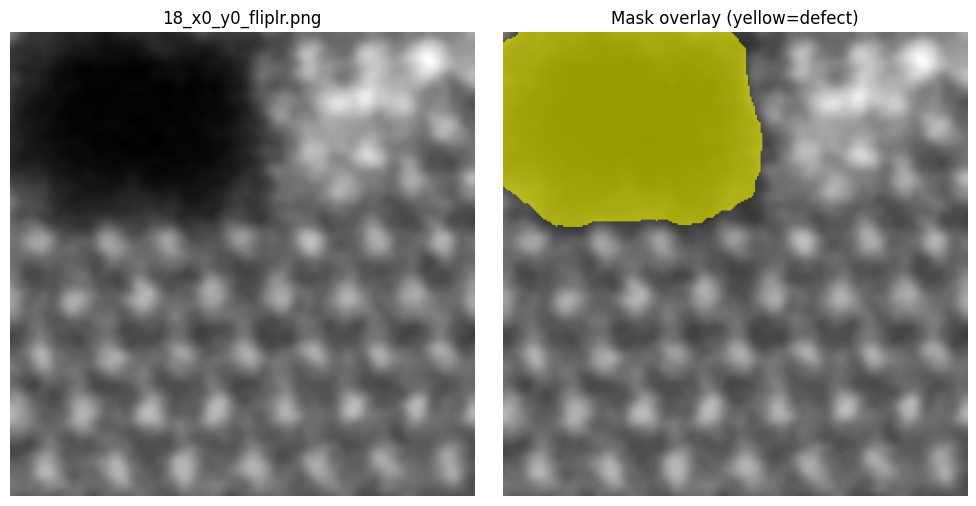

In [11]:
# ============================================================
# Quick sanity-check visualisation
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

CLASS_COLORS = {
    0: 'black',      # background
    1: 'yellow',     # defect
}

# Pick the first train patch that has annotations
train_imgs  = sorted(os.listdir(paths['images_train']))
train_masks = sorted(os.listdir(paths['masks_train']))

for fname in train_imgs[:10]:
    img  = np.array(Image.open(os.path.join(paths['images_train'], fname)))
    mask = np.array(Image.open(os.path.join(paths['masks_train'], fname)))
    if mask.max() > 0:
        break

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title(fname)
axes[0].axis('off')

# Colour-coded mask overlay
rgba = np.zeros((*mask.shape, 4), dtype=np.float32)
for cls_id, color in CLASS_COLORS.items():
    if cls_id == 0:
        continue
    rgb = mcolors.to_rgb(color)
    rgba[mask == cls_id, :3] = rgb
    rgba[mask == cls_id, 3]  = 0.6

axes[1].imshow(img, cmap='gray')
axes[1].imshow(rgba)
axes[1].set_title('Mask overlay (yellow=defect)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Class balance stats
# ============================================================
from collections import Counter

class_names = {0: 'background', 1: 'defect'}
pixel_counts = Counter()

for fname in os.listdir(paths['masks_train']):
    m = np.array(Image.open(os.path.join(paths['masks_train'], fname)))
    for cls in range(NUM_CLASSES):
        pixel_counts[cls] += int((m == cls).sum())

total = sum(pixel_counts.values())
print('Train pixel class distribution:')
for cls in range(NUM_CLASSES):
    pct = 100 * pixel_counts[cls] / total
    print(f'  Class {cls} ({class_names[cls]}): {pixel_counts[cls]:>12,} px  ({pct:.3f}%)')

Train pixel class distribution:
  Class 0 (background):    1,779,950 px  (90.533%)
  Class 1 (defect):      186,130 px  (9.467%)


---
# Part 2 - U-Net Training (Binary Defect Segmentation)

Trains a custom U-Net on the MoS? defect dataset.

**2 output classes**: background, defect

The single foreground class is `defect`.

Loss: **Focal CrossEntropy + focal Tversky**, with defect-focused validation selection

In [13]:
# Print which source images have LabelMe JSON annotations
# mos2/ contains training labeled images; mos2_val_images_labeled/ contains val labeled images
MOS2_DIR = './mos2'
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp')

def _sort_key(name):
    stem = os.path.splitext(name)[0]
    return (0, int(stem)) if stem.isdigit() else (1, stem)

json_files = sorted(
    [name for name in os.listdir(MOS2_DIR) if name.lower().endswith('.json')],
    key=_sort_key,
)

labeled_images = []
missing_images = []
for json_name in json_files:
    stem = os.path.splitext(json_name)[0]
    image_name = next(
        (stem + ext for ext in IMAGE_EXTENSIONS
         if os.path.exists(os.path.join(MOS2_DIR, stem + ext))),
        None,
    )
    if image_name is None:
        missing_images.append(json_name)
    else:
        labeled_images.append(image_name)

labeled_ids = [os.path.splitext(name)[0] for name in json_files]
print(f'Labeled image IDs ({len(labeled_ids)}):')
print(labeled_ids)
#print(f'Images with labels ({len(labeled_images)}):')
#print(labeled_images)
if missing_images:
    print(f'JSON files without matching image: {missing_images}')


Labeled image IDs (5):
['18', '19', '23', '26', '28']


In [14]:
#!pip install tqdm

In [15]:
#!pip install torch torchvision tqdm scikit-learn


## 2.1 Dataset + DataLoader


In [16]:
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T

NUM_CLASSES = 2   # background(0) + defect(1)
CLASS_NAMES = ['background', 'defect']
TARGET_CLASS_IDS = (1,)

# Collapse any legacy L1 masks into the binary encoding: 0=background, 1=defect.
_REMAP = np.array([0, 1, 1, 1], dtype=np.int64)

_SAMPLE_BONUS = {1: 3.0}

class MoS2Dataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.files = sorted(os.listdir(img_dir))
        self.img_tf = T.ToTensor()
        self.sample_weights = self._build_sample_weights()

    def _load_mask_array(self, name):
        mask = Image.open(os.path.join(self.mask_dir, name)).convert('L')
        return _REMAP[np.array(mask)]

    def _build_sample_weights(self):
        weights = []
        for name in self.files:
            classes = set(np.unique(self._load_mask_array(name)).tolist())
            classes.discard(0)
            bonus = max((_SAMPLE_BONUS.get(int(cls), 0.0) for cls in classes), default=0.0)
            weights.append(1.0 + bonus)
        return torch.tensor(weights, dtype=torch.double)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]

        img = Image.open(os.path.join(self.img_dir, name)).convert('L')
        mask = torch.from_numpy(self._load_mask_array(name)).long()
        img = self.img_tf(img)

        return img, mask, name

## 2.2 U-Net Architecture


In [17]:
import torch.nn as nn

def make_group_norm(num_channels, max_groups=8):
    groups = min(max_groups, num_channels)
    while num_channels % groups != 0:
        groups -= 1
    return nn.GroupNorm(groups, num_channels)

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            make_group_norm(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            make_group_norm(out_c),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        self.d1 = DoubleConv(1, 32)
        self.d2 = DoubleConv(32, 64)
        self.d3 = DoubleConv(64, 128)
        self.d4 = DoubleConv(128, 256, dropout=0.10)
        self.bottleneck = DoubleConv(256, 512, dropout=0.25)

        self.u4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.uconv4 = DoubleConv(512, 256, dropout=0.10)
        self.u3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.uconv3 = DoubleConv(256, 128)
        self.u2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.uconv2 = DoubleConv(128, 64)
        self.u1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.uconv1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        c1 = self.d1(x)
        c2 = self.d2(self.pool(c1))
        c3 = self.d3(self.pool(c2))
        c4 = self.d4(self.pool(c3))
        bn = self.bottleneck(self.pool(c4))

        x = self.uconv4(torch.cat([self.u4(bn), c4], dim=1))
        x = self.uconv3(torch.cat([self.u3(x), c3], dim=1))
        x = self.uconv2(torch.cat([self.u2(x), c2], dim=1))
        x = self.uconv1(torch.cat([self.u1(x), c1], dim=1))

        return self.out(x)   # (B, num_classes, H, W) logits


## 2.3 Loss function (CrossEntropy + Binary Defect Dice)


In [18]:
import torch.nn as nn
import torch.nn.functional as F

CLASS_WEIGHT_MULTIPLIERS = torch.tensor([1.0, 3.0], dtype=torch.float32)

def compute_class_weights(mask_dir, num_classes, max_weight=24.0, power=0.35):
    pixel_counts = torch.zeros(num_classes, dtype=torch.float64)

    for name in sorted(os.listdir(mask_dir)):
        mask = Image.open(os.path.join(mask_dir, name)).convert('L')
        mask = _REMAP[np.array(mask)]
        values, counts = np.unique(mask, return_counts=True)
        for value, count in zip(values, counts):
            pixel_counts[int(value)] += int(count)

    freqs = pixel_counts / pixel_counts.sum().clamp_min(1)
    weights = (freqs.max() / freqs.clamp_min(1e-12)) ** power
    weights = weights / weights[0]
    weights = weights.float() * CLASS_WEIGHT_MULTIPLIERS
    weights = weights / weights[0]
    weights = torch.clamp(weights, max=max_weight)
    return weights.float(), pixel_counts.long()

CLASS_WEIGHTS, PIXEL_COUNTS = compute_class_weights('mos2_dataset/masks/train', NUM_CLASSES)

def focal_ce_loss(logits, targets, class_weights, gamma=1.5, label_smoothing=0.02):
    ce = F.cross_entropy(
        logits,
        targets,
        reduction='none',
        weight=class_weights.to(logits.device),
        label_smoothing=label_smoothing,
    )
    pt = torch.exp(-ce)
    return (((1 - pt) ** gamma) * ce).mean()

def focal_tversky_loss(logits, targets, class_weights, alpha=0.7, beta=0.3, gamma=1.33, smooth=1e-6):
    probs = F.softmax(logits, dim=1)
    losses = []
    weights = []

    target_weights = class_weights[list(TARGET_CLASS_IDS)].to(logits.device)
    target_weights = target_weights / target_weights.sum()

    for class_idx, class_weight in zip(TARGET_CLASS_IDS, target_weights):
        pred = probs[:, class_idx]
        truth = (targets == class_idx).float()
        if truth.sum() == 0:
            continue
        tp = (pred * truth).sum()
        fp = (pred * (1 - truth)).sum()
        fn = ((1 - pred) * truth).sum()
        tversky = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
        losses.append((1 - tversky) ** gamma)
        weights.append(class_weight)

    if not losses:
        return logits.sum() * 0.0

    losses = torch.stack(losses)
    weights = torch.stack(weights)
    return (losses * weights).sum() / weights.sum()

def total_loss(logits, targets, class_weights):
    # Baseline: Focal Cross-Entropy only (Tversky term removed)
    # TODO: restore combined loss:
    # return focal_ce_loss(logits, targets, class_weights) + 0.45 * focal_tversky_loss(logits, targets, class_weights)
    return focal_ce_loss(logits, targets, class_weights)

print(f'NUM_CLASSES = {NUM_CLASSES}')
print('Train pixel counts:')
for c, name in enumerate(CLASS_NAMES):
    print(f'  {c} {name:<12} {PIXEL_COUNTS[c].item():>12,} px')
print('\nFocused class weights (boosting defect):')
for c, name in enumerate(CLASS_NAMES):
    print(f'  {c} {name:<12} {CLASS_WEIGHTS[c].item():.2f}')

NUM_CLASSES = 2
Train pixel counts:
  0 background      1,779,950 px
  1 defect            186,130 px

Focused class weights (boosting defect):
  0 background   1.00
  1 defect       6.61


## 2.4 Training the U-Net for semantic segmenation task


In [19]:
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Using device:', device)


Using device: cuda


In [20]:
from tqdm import tqdm

BATCH_SIZE = 2 
EPOCHS = 10   # Baseline: 10 epochs -- TODO: increase to 20-30 for a fully trained model
LR = 1e-4
WEIGHT_DECAY = 3e-4
EARLY_STOPPING_PATIENCE = 3
CLASS_CONFIDENCE_THRESHOLDS = {1: 0.50}

print(f'batch_size={BATCH_SIZE}, epochs={EPOCHS}, lr={LR}, weight_decay={WEIGHT_DECAY}')
print(f'class confidence thresholds: {CLASS_CONFIDENCE_THRESHOLDS}')

train_ds = MoS2Dataset('mos2_dataset/images/train', 'mos2_dataset/masks/train')
val_ds = MoS2Dataset('mos2_dataset/images/val', 'mos2_dataset/masks/val')

train_sampler = WeightedRandomSampler(
    weights=train_ds.sample_weights,
    num_samples=len(train_ds),
    replacement=True,
)

print(f'train sample weight range: {float(train_ds.sample_weights.min()):.1f} - {float(train_ds.sample_weights.max()):.1f}')

pin_memory = device.type == 'cuda'
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0, pin_memory=pin_memory)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_memory)

model = UNet(num_classes=NUM_CLASSES).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
class_weights = CLASS_WEIGHTS.to(device)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=3)

def decode_predictions(logits, class_thresholds=CLASS_CONFIDENCE_THRESHOLDS):
    probs = F.softmax(logits, dim=1)
    confidence, preds = probs.max(dim=1)
    preds = preds.clone()
    for class_idx, threshold in class_thresholds.items():
        preds[(preds == class_idx) & (confidence < threshold)] = 0
    return preds

def accumulate_iou(intersection, union, logits, targets):
    preds = decode_predictions(logits)
    for class_idx in range(NUM_CLASSES):
        pred_mask = preds == class_idx
        true_mask = targets == class_idx
        intersection[class_idx] += (pred_mask & true_mask).sum().item()
        union[class_idx] += (pred_mask | true_mask).sum().item()

def run_epoch(model, loader, class_weights, device, optimizer=None, desc='Train'):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total = 0.0
    intersection = torch.zeros(NUM_CLASSES, dtype=torch.float64)
    union = torch.zeros(NUM_CLASSES, dtype=torch.float64)
    iterator = tqdm(loader, desc=desc, leave=False)

    for x, y, _ in iterator:
        x = x.to(device, non_blocking=pin_memory)
        y = y.to(device, non_blocking=pin_memory)

        if is_train:
            optimizer.zero_grad()
            logits = model(x)
            loss = total_loss(logits, y, class_weights)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        else:
            with torch.no_grad():
                logits = model(x)
                loss = total_loss(logits, y, class_weights)

        total += loss.item()
        accumulate_iou(intersection, union, logits.detach(), y)
        iterator.set_postfix(loss=f'{loss.item():.4f}')

    iou = intersection / union.clamp_min(1.0)
    target_iou = iou[list(TARGET_CLASS_IDS)].mean().item()
    return total / len(loader), iou, target_iou

best_val_target_iou = -1.0
epochs_without_improvement = 0
history = {'train': [], 'val': [], 'lr': [], 'train_target_iou': [], 'val_target_iou': []}

for epoch in range(EPOCHS):
    train_loss, train_iou, train_target_iou = run_epoch(model, train_loader, class_weights, device, optimizer=opt, desc=f'Train {epoch + 1}/{EPOCHS}')
    val_loss, val_iou, val_target_iou = run_epoch(model, val_loader, class_weights, device, optimizer=None, desc=f'Val {epoch + 1}/{EPOCHS}')

    current_lr = opt.param_groups[0]['lr']
    history['train'].append(train_loss)
    history['val'].append(val_loss)
    history['lr'].append(current_lr)
    history['train_target_iou'].append(train_target_iou)
    history['val_target_iou'].append(val_target_iou)

    print(f'Epoch {epoch + 1:02d}  Train loss: {train_loss:.4f}  Val loss: {val_loss:.4f}  Train IoU: {train_target_iou:.4f}  Val IoU: {val_target_iou:.4f}  LR: {current_lr:.2e}')

    scheduler.step(val_target_iou)

    if val_target_iou > best_val_target_iou:
        best_val_target_iou = val_target_iou
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'unet_best.pt')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(f'Early stopping after {epoch + 1} epochs.')
            break

print(f'\nTraining complete. Best val defect IoU: {best_val_target_iou:.4f}')
print('Model saved to unet_best.pt')


batch_size=2, epochs=10, lr=0.0001, weight_decay=0.0003
class confidence thresholds: {1: 0.5}
train sample weight range: 4.0 - 4.0


Epoch 01  Train loss: 0.3142  Val loss: 0.1760  Train IoU: 0.3573  Val IoU: 0.6885  LR: 1.00e-04


Epoch 02  Train loss: 0.1603  Val loss: 0.1689  Train IoU: 0.6992  Val IoU: 0.7707  LR: 1.00e-04


Epoch 03  Train loss: 0.1282  Val loss: 0.1801  Train IoU: 0.7307  Val IoU: 0.7835  LR: 1.00e-04


Epoch 04  Train loss: 0.1061  Val loss: 0.1286  Train IoU: 0.8366  Val IoU: 0.8111  LR: 1.00e-04


Epoch 05  Train loss: 0.1043  Val loss: 0.1205  Train IoU: 0.7727  Val IoU: 0.7905  LR: 1.00e-04


Epoch 06  Train loss: 0.1070  Val loss: 0.1018  Train IoU: 0.7604  Val IoU: 0.7609  LR: 1.00e-04


Epoch 07  Train loss: 0.0843  Val loss: 0.1411  Train IoU: 0.8565  Val IoU: 0.7943  LR: 1.00e-04
Early stopping after 7 epochs.

Training complete. Best val defect IoU: 0.8111
Model saved to unet_best.pt


## 2.4b Training History

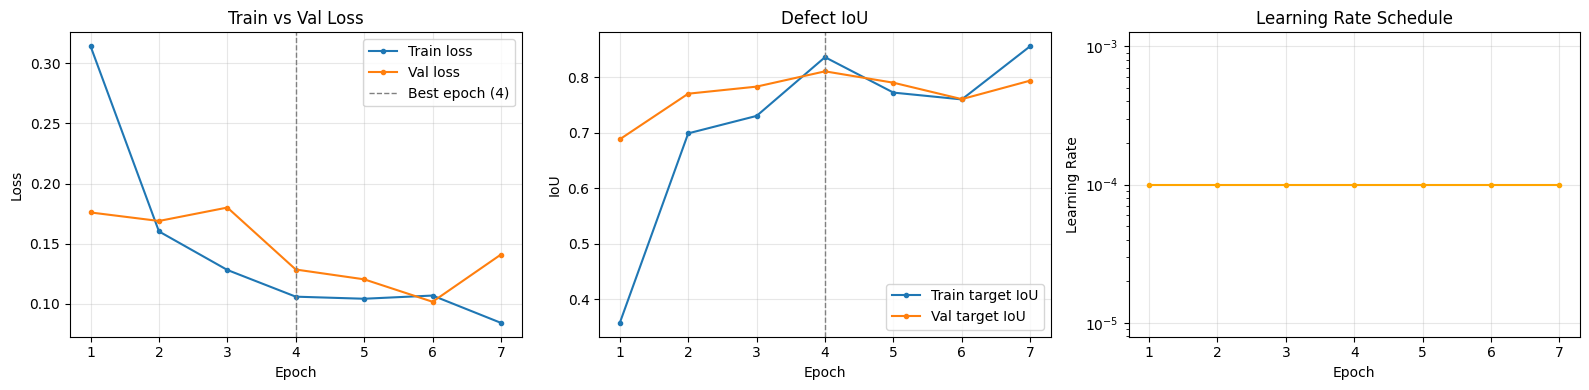

Best val defect IoU: 0.8111 at epoch 4


In [21]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curves
axes[0].plot(epochs_range, history['train'], label='Train loss', marker='o', markersize=3)
axes[0].plot(epochs_range, history['val'], label='Val loss', marker='o', markersize=3)
best_epoch = history['val_target_iou'].index(max(history['val_target_iou'])) + 1
axes[0].axvline(best_epoch, color='gray', linestyle='--', linewidth=1, label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Train vs Val Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Target IoU curves
axes[1].plot(epochs_range, history['train_target_iou'], label='Train target IoU', marker='o', markersize=3)
axes[1].plot(epochs_range, history['val_target_iou'], label='Val target IoU', marker='o', markersize=3)
axes[1].axvline(best_epoch, color='gray', linestyle='--', linewidth=1)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('IoU')
axes[1].set_title('Defect IoU')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# LR schedule
axes[2].plot(epochs_range, history['lr'], color='orange', marker='o', markersize=3)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best val defect IoU: {max(history["val_target_iou"]):.4f} at epoch {best_epoch}')


## 2.5 Visualise Predictions


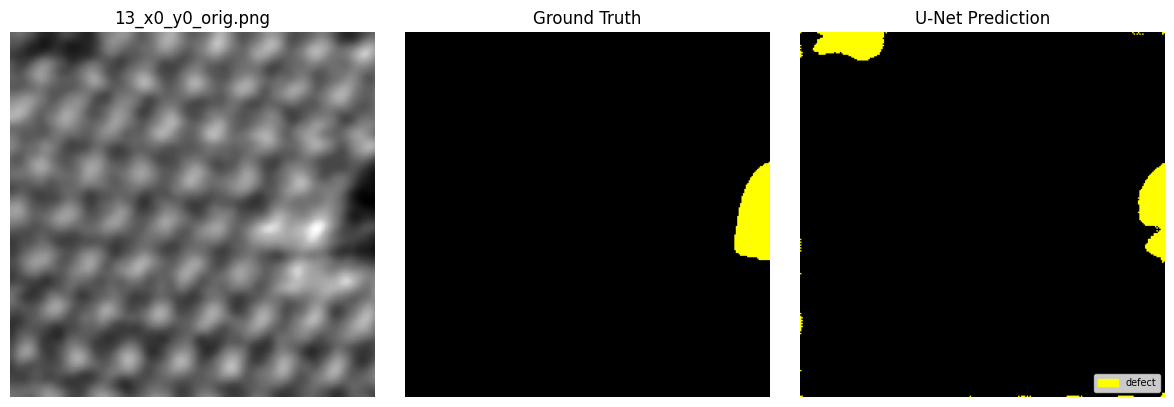

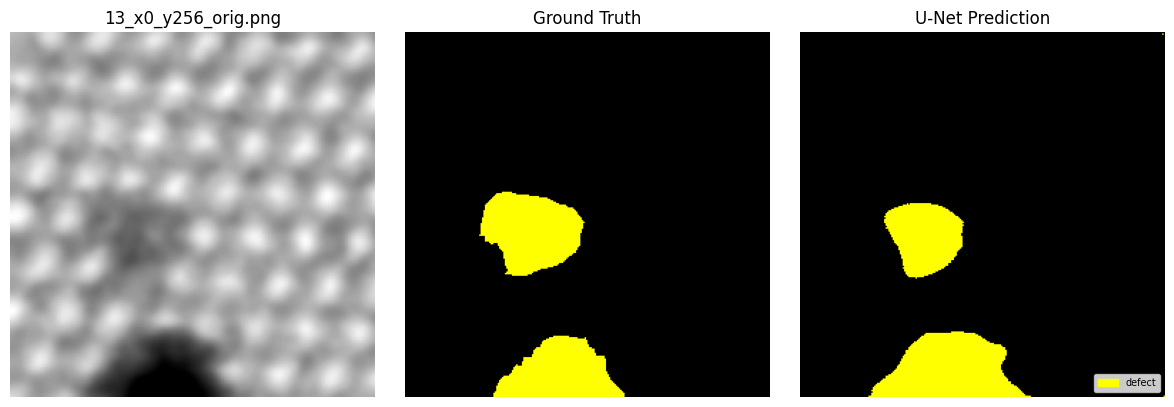

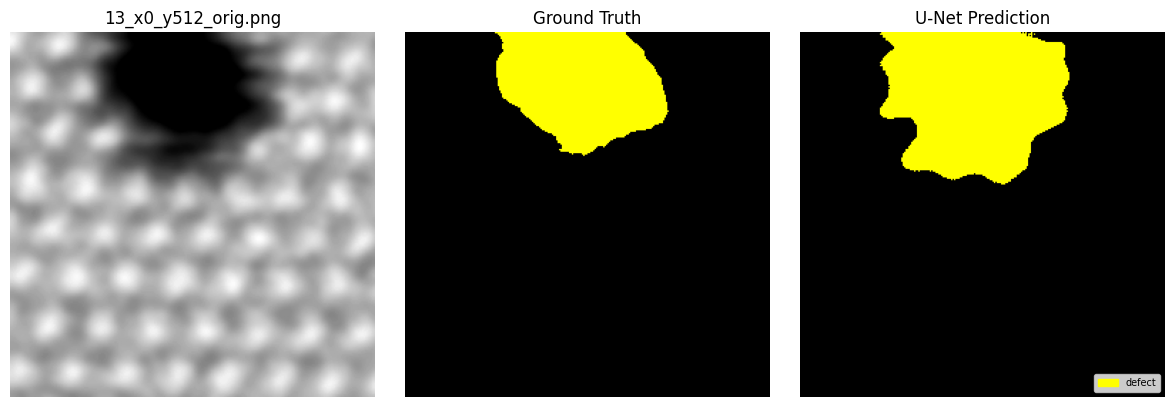

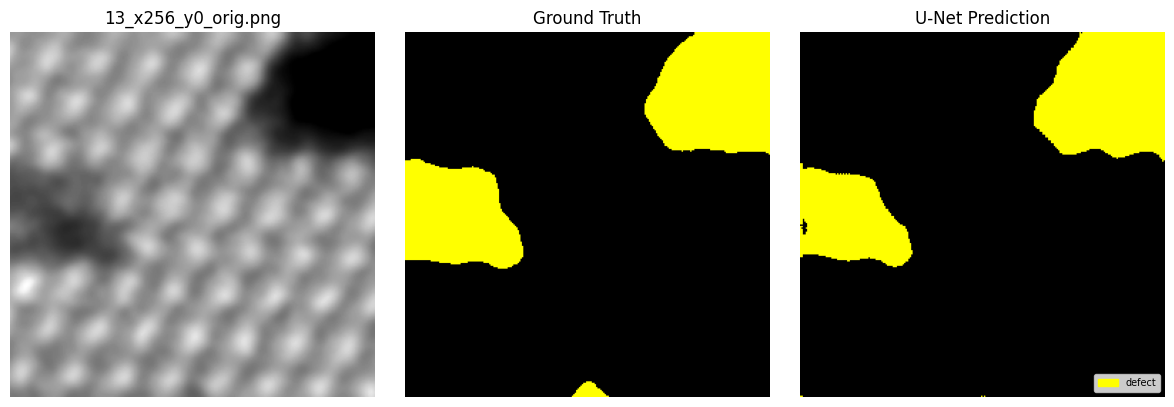

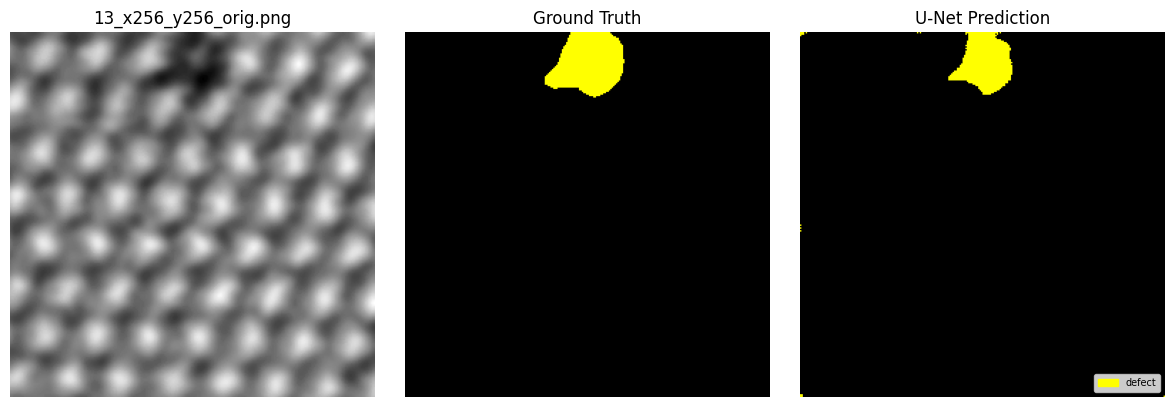

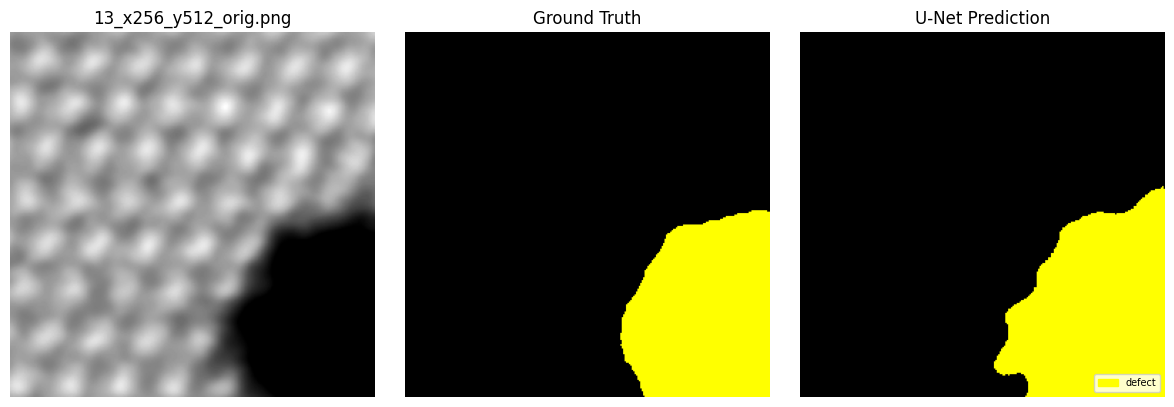

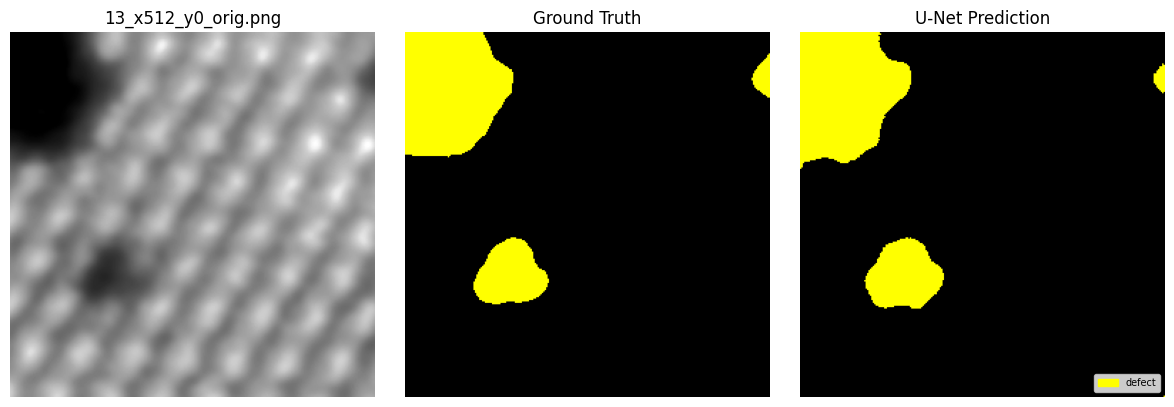

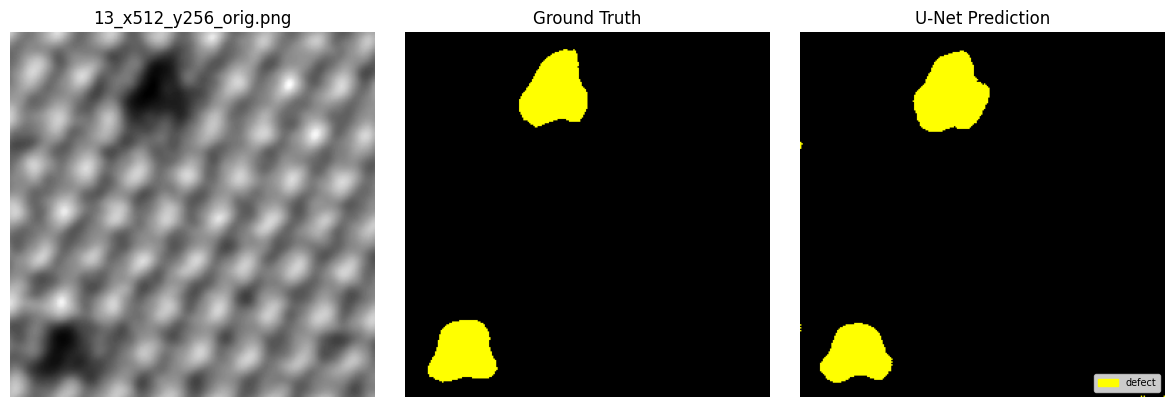

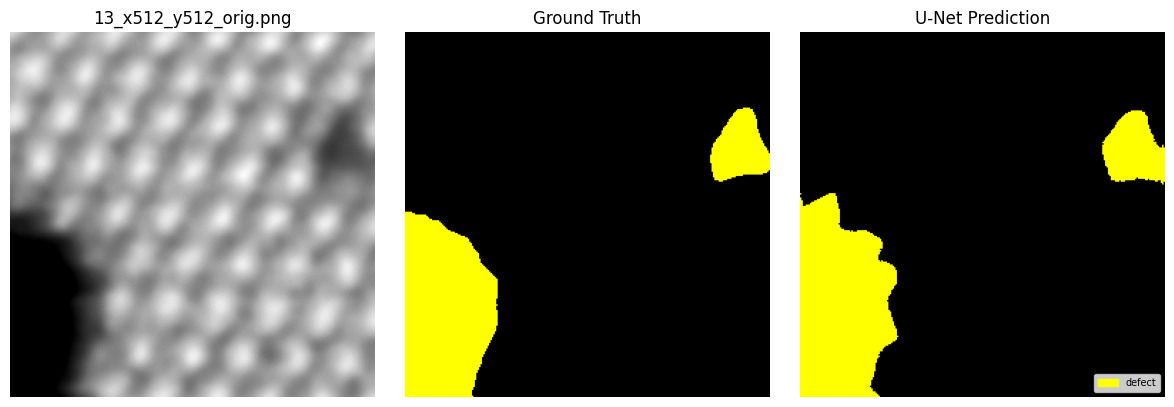

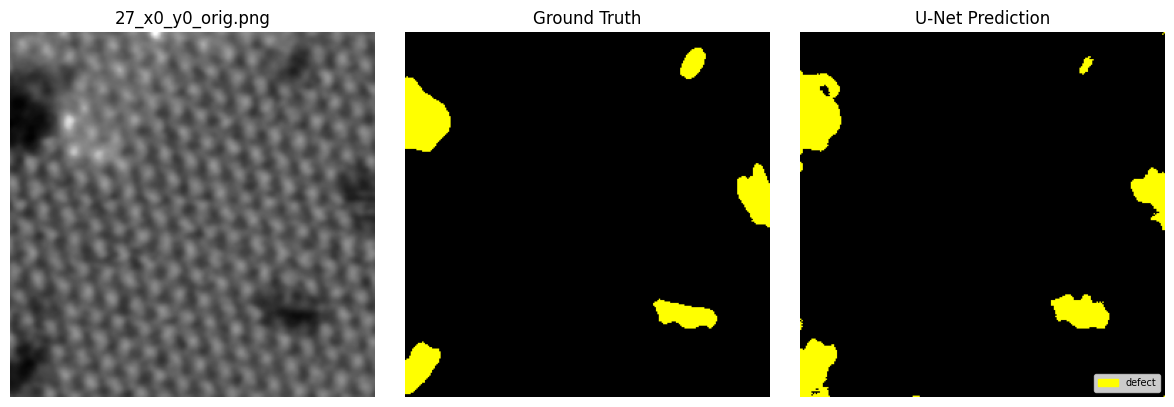

Saved 10 visualisations to unet_visualizations/val


In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# 2-class palette: background, defect
PALETTE = np.array([
    [0,   0,   0  ],   # 0 background - black
    [255, 255, 0  ],   # 1 defect     - yellow
], dtype=np.uint8)

def mask_to_rgb(mask):
    display = mask
    display = np.clip(display, 0, len(PALETTE) - 1)
    return PALETTE[display]


def visualize_unet(model, loader, device, save_dir='unet_visualizations/val', show=True):
    os.makedirs(save_dir, exist_ok=True)
    model.eval()
    count = 0

    with torch.no_grad():
        for x, y, names in loader:
            x = x.to(device)
            logits = model(x)
            preds = decode_predictions(logits).cpu().numpy()
            y_np  = y.numpy()

            for i in range(x.shape[0]):
                img  = x[i, 0].cpu().numpy()
                gt   = mask_to_rgb(y_np[i])
                pred = mask_to_rgb(preds[i])

                fig, axes = plt.subplots(1, 3, figsize=(12, 4))
                axes[0].imshow(img,  cmap='gray'); axes[0].set_title(names[i]);           axes[0].axis('off')
                axes[1].imshow(gt);                axes[1].set_title('Ground Truth');     axes[1].axis('off')
                axes[2].imshow(pred);              axes[2].set_title('U-Net Prediction'); axes[2].axis('off')

                patches = [mpatches.Patch(color=np.array(c)/255, label=n)
                           for n, c in zip(CLASS_NAMES[1:], PALETTE[1:])]
                axes[2].legend(handles=patches, loc='lower right', fontsize=7)

                plt.tight_layout()
                plt.savefig(os.path.join(save_dir, names[i].replace('.png', '_viz.png')),
                            dpi=200, bbox_inches='tight')
                count += 1
                if show:
                    plt.show()
                else:
                    plt.close()

    print(f'Saved {count} visualisations to {save_dir}')


model.load_state_dict(torch.load('unet_best.pt', map_location=device))
visualize_unet(model, val_loader, device, show=True)

In [23]:
# ============================================================
# Per-class IoU on validation set
# ============================================================

def compute_iou(model, loader, device, num_classes):
    model.eval()
    intersection = torch.zeros(num_classes, dtype=torch.float64)
    union = torch.zeros(num_classes, dtype=torch.float64)

    with torch.no_grad():
        for x, y, _ in loader:
            x = x.to(device, non_blocking=pin_memory)
            pred = decode_predictions(model(x)).cpu()
            y_cpu = y.cpu()
            for c in range(num_classes):
                p = pred == c
                t = y_cpu == c
                intersection[c] += (p & t).sum().item()
                union[c] += (p | t).sum().item()

    return intersection / union.clamp_min(1.0)


iou = compute_iou(model, val_loader, device, NUM_CLASSES)
print('\nPer-class IoU (validation):')
for c, name in enumerate(CLASS_NAMES):
    print(f'  Class {c} ({name}): {iou[c]:.4f}')
print(f'  Mean IoU (defect): {iou[list(TARGET_CLASS_IDS)].mean():.4f}')


Per-class IoU (validation):
  Class 0 (background): 0.9775
  Class 1 (defect): 0.8111
  Mean IoU (defect): 0.8111


---
# Part 3 - U-Net Prediction on Unlabeled Test Images

* Load the best U-Net weights from Part 2 and predict binary defect masks for unlabeled source images `2.png` through `12.png`.

* Each output plot places the original image on the left and the predicted defect mask on the right.

In [24]:
import os
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torchvision.transforms as T

NUM_CLASSES = 2
CLASS_NAMES = ['background', 'defect']
CLASS_CONFIDENCE_THRESHOLDS = {1: 0.50}

SOURCE_DIR = Path('mos2_test_images_unlabeled')
TEST_IMAGE_IDS = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  # unlabeled test images
MODEL_PATH = Path('unet_best.pt')
SAVE_DIR = Path('unet_visualizations/L3_test_on_new_images')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('Using device:', device)
print('Saving plots to:', SAVE_DIR)

Using device: cuda
Saving plots to: unet_visualizations\L3_test_on_new_images


## 3.1 Model

This is the same binary U-Net architecture used in L2, so the saved `unet_best.pt` weights load into the matching layers.

In [25]:
def make_group_norm(num_channels, max_groups=8):
    groups = min(max_groups, num_channels)
    while num_channels % groups != 0:
        groups -= 1
    return nn.GroupNorm(groups, num_channels)


class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            make_group_norm(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            make_group_norm(out_c),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class UNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        self.d1 = DoubleConv(1, 32)
        self.d2 = DoubleConv(32, 64)
        self.d3 = DoubleConv(64, 128)
        self.d4 = DoubleConv(128, 256, dropout=0.10)
        self.bottleneck = DoubleConv(256, 512, dropout=0.25)

        self.u4 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.uconv4 = DoubleConv(512, 256, dropout=0.10)
        self.u3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.uconv3 = DoubleConv(256, 128)
        self.u2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.uconv2 = DoubleConv(128, 64)
        self.u1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.uconv1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        c1 = self.d1(x)
        c2 = self.d2(self.pool(c1))
        c3 = self.d3(self.pool(c2))
        c4 = self.d4(self.pool(c3))
        bn = self.bottleneck(self.pool(c4))

        x = self.uconv4(torch.cat([self.u4(bn), c4], dim=1))
        x = self.uconv3(torch.cat([self.u3(x), c3], dim=1))
        x = self.uconv2(torch.cat([self.u2(x), c2], dim=1))
        x = self.uconv1(torch.cat([self.u1(x), c1], dim=1))

        return self.out(x)

## 3.2 Load Best L2 Weights

In [26]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f'Model weights not found: {MODEL_PATH}')

model = UNet(num_classes=NUM_CLASSES).to(device)
try:
    state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print(f'Loaded model weights from {MODEL_PATH}')

Loaded model weights from unet_best.pt


## 3.3 Prediction Helpers

The L2 U-Net downsamples four times, so this pads each image to a multiple of 16 before prediction, then crops the mask back to the original image size.

In [27]:
img_tf = T.ToTensor()

PALETTE = np.array([
    [0, 0, 0],       # background
    [255, 255, 0],   # defect
], dtype=np.uint8)


def decode_predictions(logits, class_thresholds=CLASS_CONFIDENCE_THRESHOLDS):
    probs = F.softmax(logits, dim=1)
    confidence, preds = probs.max(dim=1)
    preds = preds.clone()
    for class_idx, threshold in class_thresholds.items():
        preds[(preds == class_idx) & (confidence < threshold)] = 0
    return preds


def pad_to_multiple(x, multiple=16):
    _, _, h, w = x.shape
    pad_h = (multiple - h % multiple) % multiple
    pad_w = (multiple - w % multiple) % multiple
    if pad_h == 0 and pad_w == 0:
        return x, (h, w)
    return F.pad(x, (0, pad_w, 0, pad_h), mode='reflect'), (h, w)


def mask_to_rgb(mask):
    mask = np.clip(mask, 0, len(PALETTE) - 1)
    return PALETTE[mask]


def predict_image(image_path):
    display_image = Image.open(image_path).convert('RGB')
    model_image = display_image.convert('L')
    x = img_tf(model_image).unsqueeze(0).to(device)
    x, (orig_h, orig_w) = pad_to_multiple(x, multiple=16)

    with torch.no_grad():
        logits = model(x)
        pred = decode_predictions(logits)[0, :orig_h, :orig_w].cpu().numpy().astype(np.uint8)
        defect_prob = F.softmax(logits, dim=1)[0, 1, :orig_h, :orig_w].cpu().numpy()

    return np.array(display_image), pred, defect_prob


def find_image_path(image_id, source_dir=SOURCE_DIR):
    extensions = ['.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp']
    for ext in extensions:
        candidate = source_dir / f'{image_id}{ext}'
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Could not find image {image_id} in {source_dir}')

## 3.4 Predict unlabeled images #2-12

Run this cell to display and save the two-panel plots. The predicted mask image is also saved separately as `*_pred_mask.png`.

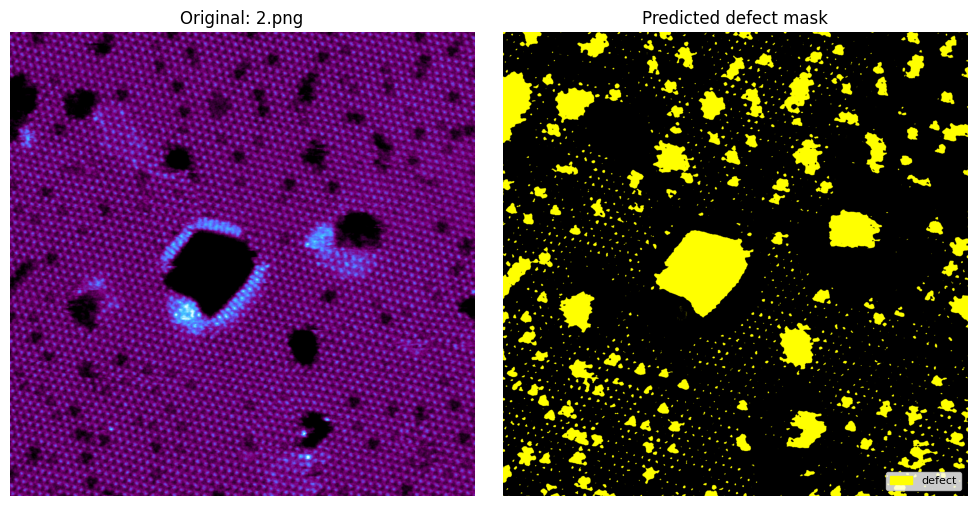

2.png: saved unet_visualizations\L3_test_on_new_images\2_original_vs_pred_mask.png; defect pixels = 651,550


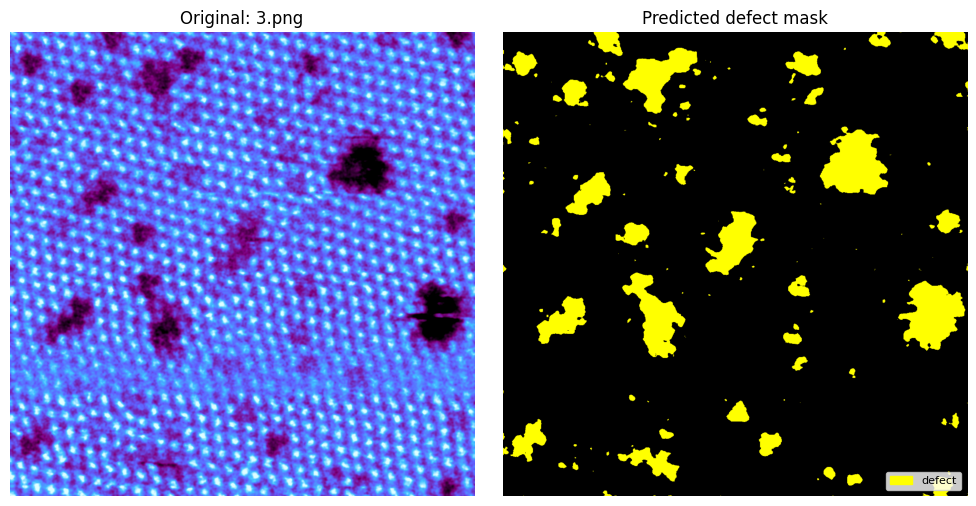

3.png: saved unet_visualizations\L3_test_on_new_images\3_original_vs_pred_mask.png; defect pixels = 112,238


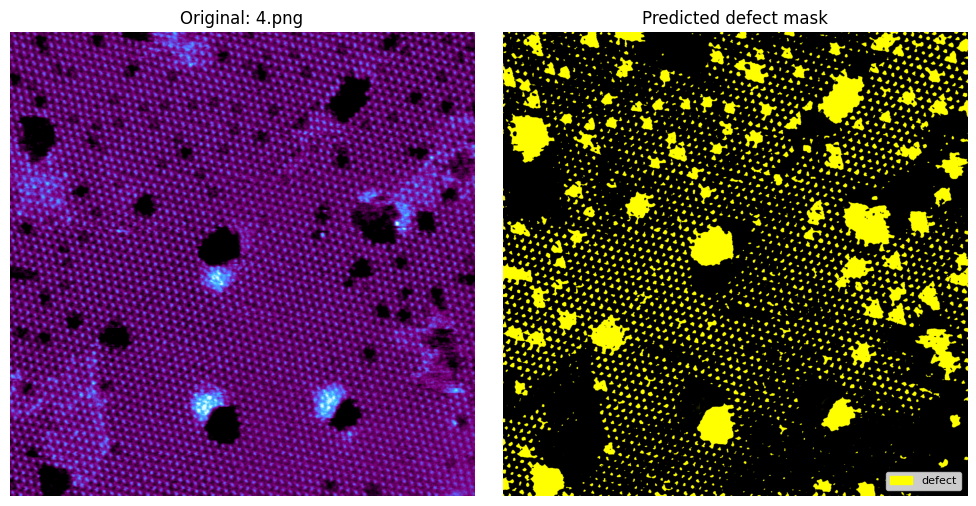

4.png: saved unet_visualizations\L3_test_on_new_images\4_original_vs_pred_mask.png; defect pixels = 831,474


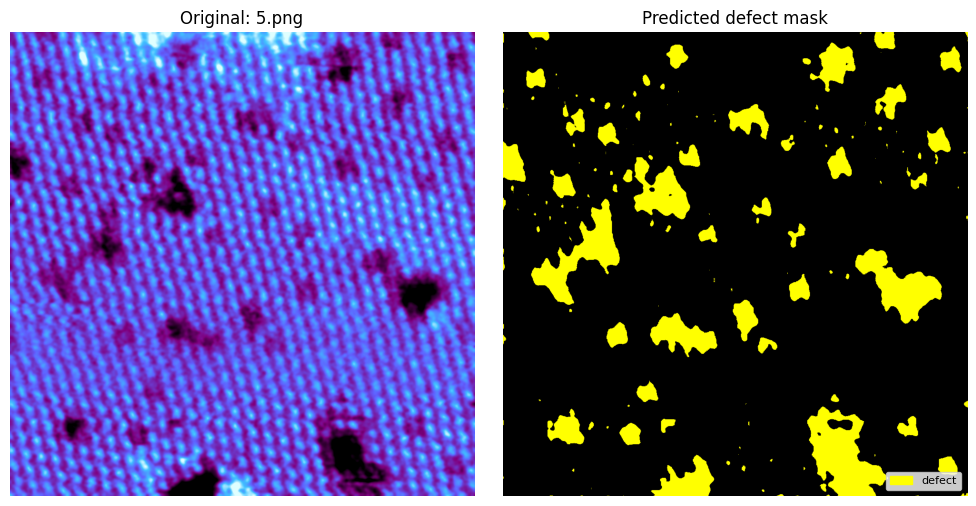

5.png: saved unet_visualizations\L3_test_on_new_images\5_original_vs_pred_mask.png; defect pixels = 129,887


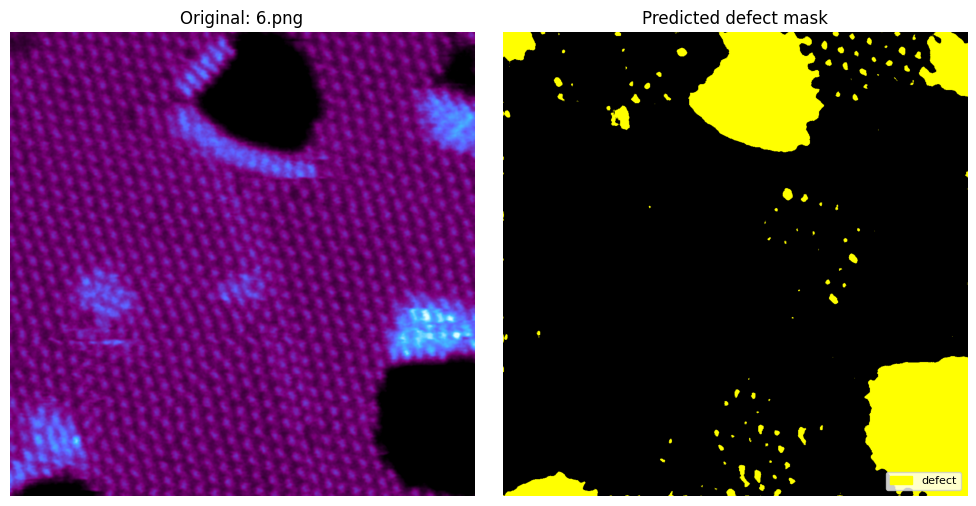

6.png: saved unet_visualizations\L3_test_on_new_images\6_original_vs_pred_mask.png; defect pixels = 148,278


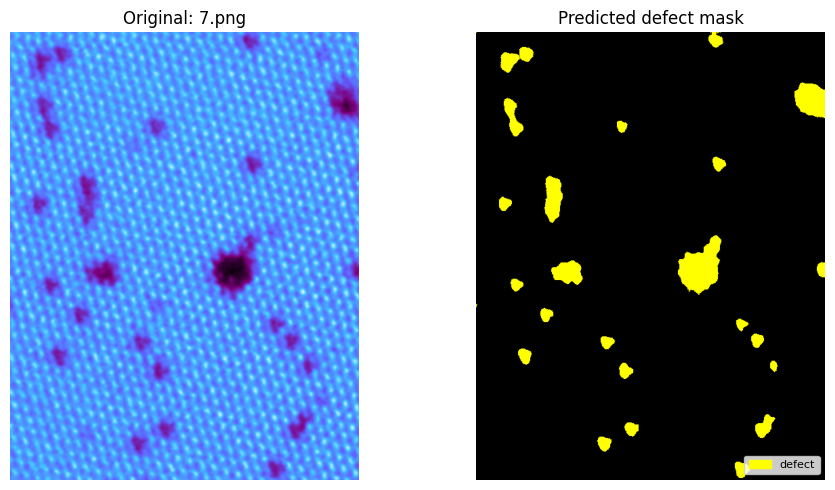

7.png: saved unet_visualizations\L3_test_on_new_images\7_original_vs_pred_mask.png; defect pixels = 14,623


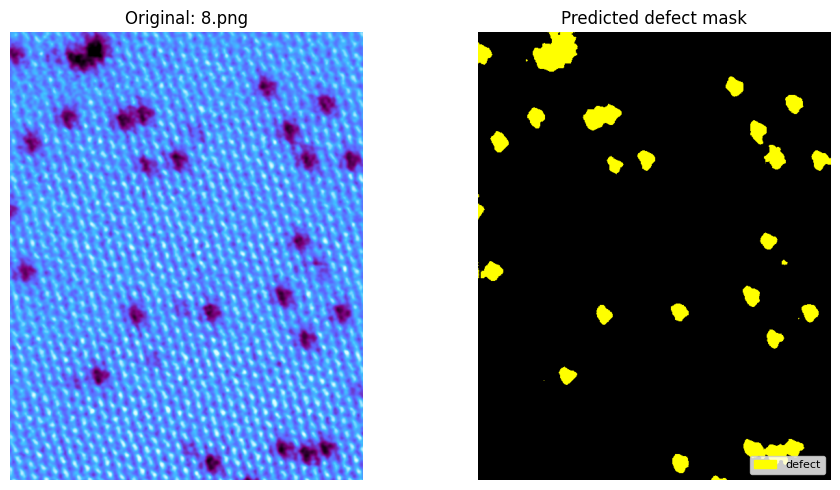

8.png: saved unet_visualizations\L3_test_on_new_images\8_original_vs_pred_mask.png; defect pixels = 15,806


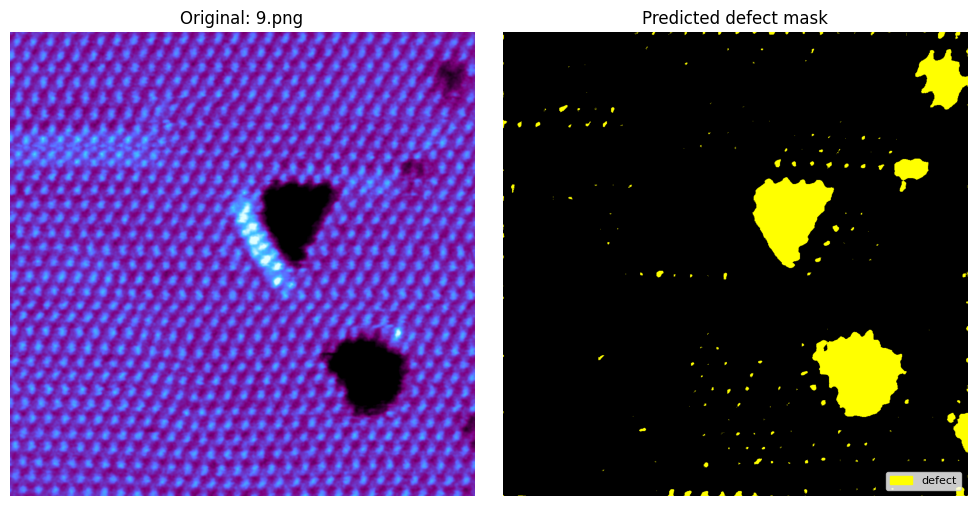

9.png: saved unet_visualizations\L3_test_on_new_images\9_original_vs_pred_mask.png; defect pixels = 66,839


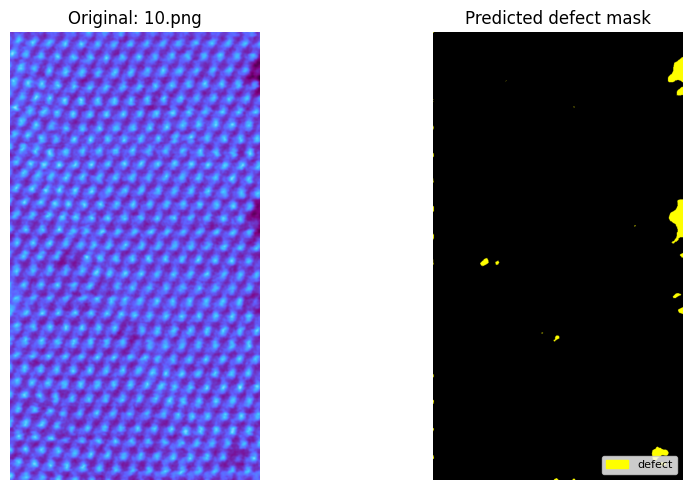

10.png: saved unet_visualizations\L3_test_on_new_images\10_original_vs_pred_mask.png; defect pixels = 4,769


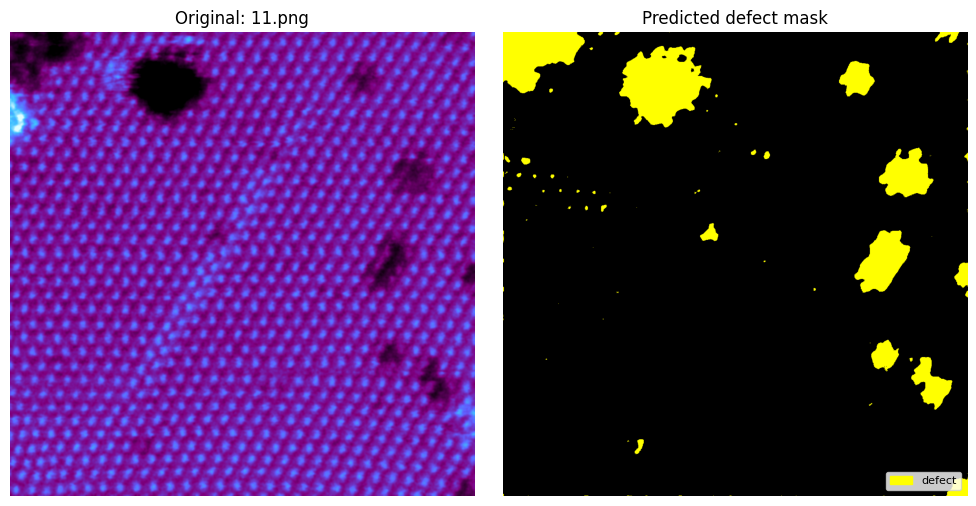

11.png: saved unet_visualizations\L3_test_on_new_images\11_original_vs_pred_mask.png; defect pixels = 75,329


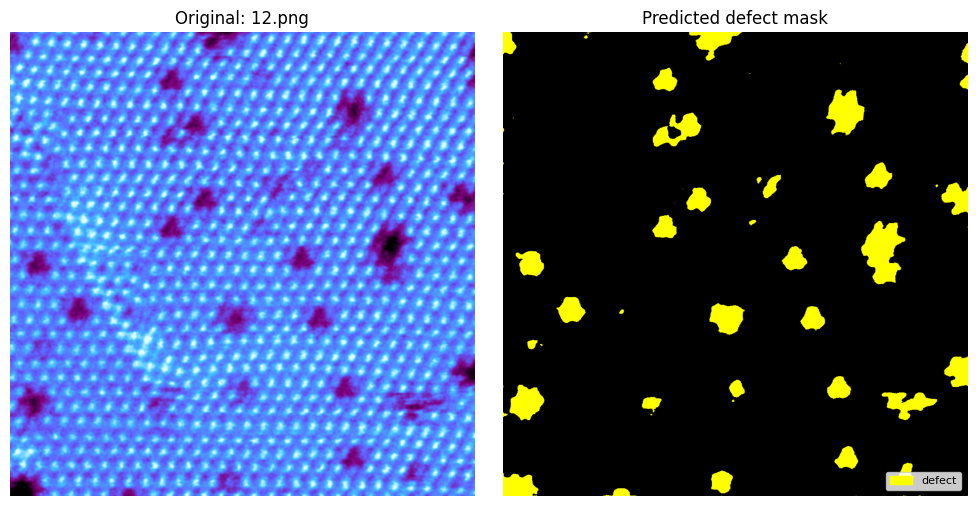

12.png: saved unet_visualizations\L3_test_on_new_images\12_original_vs_pred_mask.png; defect pixels = 69,682


In [28]:
patches = [mpatches.Patch(color=np.array(PALETTE[1]) / 255, label='defect')]

for image_id in TEST_IMAGE_IDS:
    image_path = find_image_path(image_id)
    image, pred_mask, defect_prob = predict_image(image_path)

    mask_path = SAVE_DIR / f'{image_path.stem}_pred_mask.png'
    Image.fromarray(mask_to_rgb(pred_mask)).save(mask_path)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image)
    axes[0].set_title(f'Original: {image_path.name}')
    axes[0].axis('off')

    axes[1].imshow(mask_to_rgb(pred_mask))
    axes[1].set_title('Predicted defect mask')
    axes[1].axis('off')
    axes[1].legend(handles=patches, loc='lower right', fontsize=8)

    plt.tight_layout()
    plot_path = SAVE_DIR / f'{image_path.stem}_original_vs_pred_mask.png'
    plt.savefig(plot_path, dpi=200, bbox_inches='tight')
    plt.show()

    defect_pixels = int((pred_mask == 1).sum())
    print(f'{image_path.name}: saved {plot_path}; defect pixels = {defect_pixels:,}')

---
# Questions & Answering (8 x 10 pts = 80 pts)

For each question, write your answer in a **new markdown cell directly below it**.

---
### Question 1 *(10 pts)*

Why do we need **train-validation-split** before U-Net training?

*Your answer:* 


---
### Question 2 *(10 pts)*

Why crop original images into **smaller patches**?

*Your answer:* 


---
### Question 3 *(10 pts)*

Why is **image augmentation** needed, and what other methods could be used?

*Your answer:* 


---
### Question 4 *(10 pts)*

How do we address the **class imbalance** (background ≫ defect)?

*Your answer:* 


---
### Question 5 *(10 pts)*

Explain the **U-Net architecture & skip connections**, and why they are crucial for pixel-wise segmentation.

*Your answer:* 


---
### Question 6 *(10 pts)*

Describe the **loss function(s)** and **evaluation metric(s)** used in this notebook.

*Your answer:* 


---
### Question 7 *(10 pts)*

What are the key **hyperparameters** you can fine-tune to improve performance?

*Your answer:* 


---
### Question 8 *(10 pts)*

**Evaluate** the current training history and test results -- is it good? If not, how can it be improved?

*Your answer:* 


---
### Improvement -- **20 pts**

Apply your improvement plan from Q8 (modify code, label more images, tune hyperparameters, etc.) and re-run. Points are awarded based on how much your final **defect IoU** exceeds the baseline, and on the visual cleanliness of predicted masks on the unlabeled test images.


---
### Submission

- Upload your updated `.ipynb` with every question answered (80%).
- U-Net performance improved with new results shown in the notebook (20%).

(The End)


In [29]:
from datetime import datetime

print("Finish time:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

Finish time: 2026-04-23 18:12:24
